# TSLA Intraday Liquidity Analysis with LOBSTER Data

**Course: Liquidity Games in HFT Markets — Anastasia Bugaenko, CentraleSupélec**

| Day | Topics |
|---|---|
| **Monday** | Project Introduction · Initial Data Analysis (IDA) |
| **Tuesday–Wednesday** | Exploratory Data Analysis (EDA) · Model Development |
| **Thursday** | Finite-Size Scaling Analysis · Kyle's Lambda |
| **Friday** | Group Presentation (30 min) |

---

This notebook applies the methodology from `references/Lecture_slides.pdf` to
TSLA LOBSTER data for the full year 2019 (252 trading days). It is fully
self-contained: all data preparation and analysis helpers are defined in-line.

**Scope:** only *visible* executions with `Event Type == 4` are studied.
Hidden executions (type 5) and all other LOBSTER events are excluded from
impact statistics, as per the lecture scope.

Data structure documentation:
<https://php.lobsterdata.com/info/DataStructure.php>

**Key references:**
- Bugaenko (2020), *Empirical Study of Market Impact* — `Master Thesis.pdf`
- Patzelt & Bouchaud (2017), *Universal scaling* — `Universal scaling…pdf`
- Gould et al. (2013), *Limit order books* — `Limit order books.pdf`

**Required packages:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `pyarrow`, `scipy`

## 0. Method

The workflow strictly follows the lecture-slide outline from Monday to Thursday:

**Monday — Initial Data Analysis**
1. Clone raw LOBSTER files into a working directory outside the repository
2. Merge daily `message` and `orderbook` files; keep only type-4 (visible) executions
3. Reconstruct market orders by batching executions sharing a timestamp and initiator sign
4. Visualise bid, ask, spread and mid-price; characterise the LOB depth

**Tuesday–Wednesday — Exploratory Data Analysis + Model Development**

5. Study stylised facts: heavy tails, aggregate Gaussianity, long-range sign and magnitude correlations
6. Measure unconditional impact $R(\ell)$ and lag-1 conditional impact $R(\upsilon, 1)$
7. Compute order-flow imbalance $\Delta V$ over non-overlapping windows for several horizons $T$
8. Plot $R(\Delta V, T)$ and show the concave-to-linear shape across horizons

**Thursday — Finite-Size Scaling**

9. Fit the sigmoidal FSS model $\mathcal{F}(x) = x\,(1+|x|^\alpha)^{-\beta/\alpha}$
10. Renormalise and collapse all curves onto a single master curve
11. Estimate Kyle's lambda $\lambda(T) \propto T^{-\lambda}$ in the linear region

> **LOBSTER alignment:** row $k$ of the message file describes the event
> transitioning the book from row $k-1$ to row $k$ of the order-book file.
> The mid-price *before* each execution is therefore taken from row $k-1$.

In [2]:
"""LOBSTER preparation and liquidity analysis helpers for the TSLA notebook."""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
import shutil
import subprocess
import sys
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from scipy.optimize import least_squares


PRICE_SCALE = 10_000.0
VISIBLE_EXECUTION_EVENT = 4
MESSAGE_COLUMNS = [
    "seconds",
    "event_type",
    "order_id",
    "size",
    "price_raw",
    "resting_order_direction",
]
FILE_PATTERN = re.compile(
    r"(?P<symbol>[A-Z]+)_(?P<date>\d{4}-\d{2}-\d{2})_"
    r"(?P<start>\d+)_(?P<end>\d+)_(?P<kind>message|orderbook)_"
    r"(?P<levels>\d+)\.csv"
)

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "TSLA").is_dir():
    raise RuntimeError("The raw TSLA/ directory must be present at the repository root.")

# Cloned and derived files remain outside the Git repository.
WORK_DIR = ROOT.parent / "EI_liquidity_riad_working"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

### Self-contained Preparation and Analysis Functions

The following cells contain the complete implementation used by the
notebook. No local module or external script is required.

In [3]:
@dataclass(frozen=True)
class DailyFiles:
    symbol: str
    date: str
    start: str
    end: str
    levels: int
    message_path: Path
    orderbook_path: Path


@dataclass(frozen=True)
class PreparedPaths:
    visible_executions: Path
    market_orders: Path
    daily_summary: Path


def clone_raw_data(source_dir: Path | str, destination_dir: Path | str) -> Path:
    """Create an isolated raw-data working copy, using APFS clones when possible."""

    source = Path(source_dir)
    destination = Path(destination_dir)
    if destination.exists():
        return destination
    if not source.is_dir():
        raise FileNotFoundError(f"Raw LOBSTER directory not found: {source}")

    destination.parent.mkdir(parents=True, exist_ok=True)
    if sys.platform == "darwin":
        try:
            subprocess.run(
                ["cp", "-cR", str(source), str(destination)],
                check=True,
                capture_output=True,
                text=True,
            )
            return destination
        except subprocess.CalledProcessError:
            pass

    shutil.copytree(source, destination)
    return destination


def discover_daily_files(raw_dir: Path | str, symbol: str = "TSLA") -> list[DailyFiles]:
    """Return complete daily message/orderbook pairs in chronological order."""

    raw_path = Path(raw_dir)
    grouped: dict[tuple[str, str, str, int], dict[str, Path]] = {}
    for path in sorted(raw_path.glob(f"{symbol}_*.csv")):
        match = FILE_PATTERN.fullmatch(path.name)
        if not match or match.group("symbol") != symbol:
            continue
        key = (
            match.group("date"),
            match.group("start"),
            match.group("end"),
            int(match.group("levels")),
        )
        grouped.setdefault(key, {})[match.group("kind")] = path

    pairs: list[DailyFiles] = []
    for (date, start, end, levels), files in sorted(grouped.items()):
        missing = {"message", "orderbook"} - files.keys()
        if missing:
            raise ValueError(f"Incomplete LOBSTER pair for {date}: missing {sorted(missing)}")
        pairs.append(
            DailyFiles(
                symbol=symbol,
                date=date,
                start=start,
                end=end,
                levels=levels,
                message_path=files["message"],
                orderbook_path=files["orderbook"],
            )
        )
    if not pairs:
        raise FileNotFoundError(f"No LOBSTER files found for {symbol} in {raw_path}")
    return pairs


def orderbook_columns(levels: int) -> list[str]:
    columns: list[str] = []
    for level in range(1, levels + 1):
        columns.extend(
            [
                f"ask_price_{level}",
                f"ask_size_{level}",
                f"bid_price_{level}",
                f"bid_size_{level}",
            ]
        )
    return columns


def read_visible_executions(day: DailyFiles) -> tuple[pd.DataFrame, int]:
    """Join aligned LOBSTER rows and retain visible limit-order executions only.

    LOBSTER row k describes the event that changes the book from row k - 1 to
    row k. The returned table therefore contains both pre-event and post-event
    book states. The first row is discarded when it is a type-4 event because
    its pre-event state is not available in the daily file.
    """

    messages = pd.read_csv(
        day.message_path,
        header=None,
        usecols=range(len(MESSAGE_COLUMNS)),
        names=MESSAGE_COLUMNS,
    )

    book_columns = orderbook_columns(day.levels)
    orderbook = pd.read_csv(day.orderbook_path, header=None, names=book_columns)
    if len(messages) != len(orderbook):
        raise ValueError(
            f"LOBSTER alignment failure for {day.date}: "
            f"{len(messages)} message rows != {len(orderbook)} book rows"
        )

    event_rows = np.flatnonzero(
        messages["event_type"].to_numpy() == VISIBLE_EXECUTION_EVENT
    )
    event_rows = event_rows[event_rows > 0]
    selected = messages.iloc[event_rows].reset_index(drop=True)

    before = orderbook.iloc[event_rows - 1].reset_index(drop=True)
    before.columns = [f"{column}_before" for column in before.columns]
    after = orderbook.iloc[event_rows].reset_index(drop=True)
    after.columns = [f"{column}_after" for column in after.columns]

    executions = pd.concat([selected, before, after], axis=1)
    executions.insert(0, "date", day.date)
    executions.insert(1, "timestamp", _timestamps(day.date, executions["seconds"]))
    executions.insert(3, "event_row", event_rows)
    executions["execution_price"] = executions.pop("price_raw") / PRICE_SCALE
    executions["trade_sign"] = -executions["resting_order_direction"]

    price_columns = [
        column
        for column in executions.columns
        if "_price_" in column and column.endswith(("_before", "_after"))
    ]
    executions[price_columns] = executions[price_columns] / PRICE_SCALE
    executions["mid_price_before"] = (
        executions["ask_price_1_before"] + executions["bid_price_1_before"]
    ) / 2
    executions["mid_price_after"] = (
        executions["ask_price_1_after"] + executions["bid_price_1_after"]
    ) / 2
    executions["spread_before"] = (
        executions["ask_price_1_before"] - executions["bid_price_1_before"]
    )
    executions["same_side_queue_before"] = np.where(
        executions["trade_sign"].eq(1),
        executions["ask_size_1_before"],
        executions["bid_size_1_before"],
    )
    return executions, len(messages)


def aggregate_market_orders(executions: pd.DataFrame) -> pd.DataFrame:
    """Batch visible executions sharing a timestamp and initiator direction."""

    if executions.empty:
        return executions.copy()

    ordered = executions.sort_values(["date", "event_row"]).copy()
    previous = ordered.shift()
    starts_new_order = (
        ordered["date"].ne(previous["date"])
        | ordered["seconds"].ne(previous["seconds"])
        | ordered["trade_sign"].ne(previous["trade_sign"])
        | ordered["event_row"].sub(previous["event_row"]).ne(1)
    )
    ordered["_market_order_group"] = starts_new_order.cumsum()
    keys = ["date", "_market_order_group"]
    grouped = ordered.groupby(keys, sort=True, observed=True)
    aggregations: dict[str, tuple[str, str]] = {
        "seconds": ("seconds", "first"),
        "trade_sign": ("trade_sign", "first"),
        "timestamp": ("timestamp", "first"),
        "event_type": ("event_type", "first"),
        "first_event_row": ("event_row", "first"),
        "last_event_row": ("event_row", "last"),
        "visible_execution_count": ("event_type", "size"),
        "size": ("size", "sum"),
        "resting_order_direction": ("resting_order_direction", "first"),
        "mid_price_before": ("mid_price_before", "first"),
        "mid_price_after": ("mid_price_after", "last"),
        "spread_before": ("spread_before", "first"),
        "same_side_queue_before": ("same_side_queue_before", "first"),
    }
    for column in executions.columns:
        if column.endswith("_before") and column not in {
            "mid_price_before",
            "spread_before",
            "same_side_queue_before",
        }:
            aggregations[column] = (column, "first")
        elif column.endswith("_after") and column != "mid_price_after":
            aggregations[column] = (column, "last")

    market_orders = grouped.agg(**aggregations).reset_index()
    weighted_notional = (ordered["execution_price"] * ordered["size"]).groupby(
        [ordered[column] for column in keys]
    ).sum()
    total_size = grouped["size"].sum()
    market_orders["execution_price_vwap"] = (
        weighted_notional / total_size
    ).to_numpy()
    market_orders["signed_volume"] = market_orders["trade_sign"] * market_orders["size"]
    return (
        market_orders.drop(columns="_market_order_group")
        .sort_values(["date", "first_event_row"])
        .reset_index(drop=True)
    )


def prepare_type4_dataset(
    raw_dir: Path | str,
    processed_dir: Path | str,
    symbol: str = "TSLA",
    year: int = 2019,
    force: bool = False,
) -> PreparedPaths:
    """Horizontally join daily files and vertically append annual type-4 tables."""

    output_dir = Path(processed_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = PreparedPaths(
        visible_executions=output_dir / f"{symbol}_{year}_type4_visible_executions.parquet",
        market_orders=output_dir / f"{symbol}_{year}_type4_market_orders.parquet",
        daily_summary=output_dir / f"{symbol}_{year}_type4_daily_summary.csv",
    )
    if not force and all(path.exists() for path in paths.__dict__.values()):
        return paths

    pairs = [
        pair for pair in discover_daily_files(raw_dir, symbol=symbol)
        if pair.date.startswith(f"{year}-")
    ]
    if not pairs:
        raise FileNotFoundError(f"No {symbol} LOBSTER files found for {year}")

    temporary = {
        name: path.with_suffix(path.suffix + ".tmp")
        for name, path in paths.__dict__.items()
    }
    for path in temporary.values():
        path.unlink(missing_ok=True)

    visible_writer: pq.ParquetWriter | None = None
    market_writer: pq.ParquetWriter | None = None
    summaries: list[dict[str, object]] = []
    try:
        for pair in pairs:
            executions, message_rows = read_visible_executions(pair)
            market_orders = aggregate_market_orders(executions)
            visible_writer = _append_parquet(
                visible_writer, temporary["visible_executions"], executions
            )
            market_writer = _append_parquet(
                market_writer, temporary["market_orders"], market_orders
            )
            summaries.append(
                {
                    "date": pair.date,
                    "message_rows": message_rows,
                    "visible_executions": len(executions),
                    "market_orders": len(market_orders),
                    "visible_volume": int(executions["size"].sum()),
                }
            )
    finally:
        if visible_writer is not None:
            visible_writer.close()
        if market_writer is not None:
            market_writer.close()

    pd.DataFrame(summaries).to_csv(temporary["daily_summary"], index=False)
    for name, path in paths.__dict__.items():
        temporary[name].replace(path)
    return paths

In [3]:
def add_lag1_features(market_orders: pd.DataFrame) -> pd.DataFrame:
    """Add one-trade-ahead impact and daily normalisation columns."""

    trades = market_orders.sort_values(_trade_sort_columns(market_orders)).copy()
    by_day = trades.groupby("date", sort=True, observed=True)
    trades["next_mid_price"] = by_day["mid_price_before"].shift(-1)
    trades["lag1_mid_change"] = trades["next_mid_price"] - trades["mid_price_before"]
    trades["lag1_signed_impact"] = trades["trade_sign"] * trades["lag1_mid_change"]
    trades["daily_volume"] = by_day["size"].transform("sum")
    trades["daily_r1"] = trades.groupby("date", observed=True)[
        "lag1_signed_impact"
    ].transform("mean")
    trades["average_same_side_queue"] = trades.groupby("date", observed=True)[
        "same_side_queue_before"
    ].transform("mean")
    trades["normalised_trade_volume"] = (
        trades["size"] / trades["average_same_side_queue"]
    )
    trades["normalised_lag1_impact"] = trades["lag1_signed_impact"] / trades["daily_r1"]
    return trades


def compute_response(market_orders: pd.DataFrame, max_lag: int = 50) -> pd.DataFrame:
    """Estimate unconditional response R(l) without crossing daily boundaries."""

    totals = np.zeros(max_lag, dtype=float)
    counts = np.zeros(max_lag, dtype=np.int64)
    for _, day in market_orders.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered["mid_price_before"].to_numpy(dtype=float)
        signs = ordered["trade_sign"].to_numpy(dtype=float)
        for lag in range(1, min(max_lag, len(day) - 1) + 1):
            values = signs[:-lag] * (mid[lag:] - mid[:-lag])
            valid = np.isfinite(values)
            totals[lag - 1] += values[valid].sum()
            counts[lag - 1] += valid.sum()
    response = np.divide(totals, counts, out=np.full(max_lag, np.nan), where=counts > 0)
    return pd.DataFrame({"lag": np.arange(1, max_lag + 1), "response": response, "count": counts})


def compute_event_time_returns(
    market_orders: pd.DataFrame, horizons: Sequence[int] = (1, 10, 100)
) -> pd.DataFrame:
    """Compute log returns at several market-order event-time horizons."""

    frames: list[pd.DataFrame] = []
    for horizon in horizons:
        for date, day in market_orders.groupby("date", sort=True, observed=True):
            ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
            mid = ordered["mid_price_before"]
            values = np.log(mid.shift(-horizon)) - np.log(mid)
            frames.append(
                pd.DataFrame(
                    {
                        "date": date,
                        "horizon": horizon,
                        "log_return": values.dropna().to_numpy(),
                    }
                )
            )
    return pd.concat(frames, ignore_index=True)


def autocorrelation_by_day(
    data: pd.DataFrame, value_column: str, max_lag: int = 50
) -> pd.DataFrame:
    """Estimate autocorrelation while keeping each trading day independent."""

    clean = data[["date", value_column]].dropna()
    mean = clean[value_column].mean()
    variance = clean[value_column].var(ddof=0)
    rows: list[dict[str, float | int]] = []
    for lag in range(1, max_lag + 1):
        total = 0.0
        count = 0
        for _, day in clean.groupby("date", sort=True, observed=True):
            values = day[value_column].to_numpy(dtype=float)
            if len(values) <= lag:
                continue
            total += ((values[:-lag] - mean) * (values[lag:] - mean)).sum()
            count += len(values) - lag
        rows.append(
            {
                "lag": lag,
                "autocorrelation": total / count / variance if count and variance else np.nan,
                "count": count,
            }
        )
    return pd.DataFrame(rows)


def bin_conditional_impact(
    trades: pd.DataFrame, quantiles: int = 30
) -> pd.DataFrame:
    """Average lag-1 impact conditional on normalised trade volume."""

    clean = trades.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["normalised_trade_volume", "normalised_lag1_impact"]
    )
    labels = pd.qcut(clean["normalised_trade_volume"], q=quantiles, duplicates="drop")
    return (
        clean.assign(volume_bin=labels)
        .groupby("volume_bin", observed=True)
        .agg(
            normalised_trade_volume=("normalised_trade_volume", "mean"),
            normalised_lag1_impact=("normalised_lag1_impact", "mean"),
            observations=("normalised_lag1_impact", "size"),
        )
        .reset_index(drop=True)
    )


def compute_aggregate_windows(
    trades: pd.DataFrame,
    horizons: Sequence[int] = (5, 10, 20, 50, 100),
    stride: str | int = "horizon",
) -> pd.DataFrame:
    """Compute coarse-grained signed imbalances and impact within each day.

    The notebook uses non-overlapping windows (stride == "horizon"), matching a
    coarse-graining operation while keeping the annual dataset tractable. Pass
    stride=1 to enumerate every overlapping window.
    """

    frames: list[pd.DataFrame] = []
    for date, day in trades.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered["mid_price_before"].to_numpy(dtype=float)
        size = ordered["size"].to_numpy(dtype=float)
        sign = ordered["trade_sign"].to_numpy(dtype=float)
        signed_volume = size * sign
        daily_volume = size.sum()
        daily_r1 = ordered["lag1_signed_impact"].mean()
        if not np.isfinite(daily_r1) or daily_r1 <= 0 or daily_volume <= 0:
            continue
        signed_volume_cumsum = np.r_[0.0, np.cumsum(signed_volume)]
        sign_cumsum = np.r_[0.0, np.cumsum(sign)]

        for horizon in horizons:
            step = horizon if stride == "horizon" else int(stride)
            starts = np.arange(0, len(ordered) - horizon, step)
            if not len(starts):
                continue
            stops = starts + horizon
            volume_imbalance = signed_volume_cumsum[stops] - signed_volume_cumsum[starts]
            order_flow_imbalance = sign_cumsum[stops] - sign_cumsum[starts]
            impact = mid[stops] - mid[starts]
            frames.append(
                pd.DataFrame(
                    {
                        "date": date,
                        "horizon": horizon,
                        "volume_imbalance": volume_imbalance,
                        "order_flow_imbalance": order_flow_imbalance,
                        "impact": impact,
                        "daily_volume": daily_volume,
                        "daily_r1": daily_r1,
                        "normalised_volume_imbalance": volume_imbalance / daily_volume,
                        "normalised_impact": impact / daily_r1,
                    }
                )
            )
    return pd.concat(frames, ignore_index=True)


def quantile_impact_curve(
    windows: pd.DataFrame, quantiles: int = 31
) -> pd.DataFrame:
    """Denoise aggregate impact with separate imbalance quantiles for each T."""

    frames: list[pd.DataFrame] = []
    for horizon, part in windows.groupby("horizon", sort=True, observed=True):
        labels = pd.qcut(
            part["normalised_volume_imbalance"], q=quantiles, duplicates="drop"
        )
        curve = (
            part.assign(imbalance_bin=labels)
            .groupby("imbalance_bin", observed=True)
            .agg(
                normalised_volume_imbalance=("normalised_volume_imbalance", "mean"),
                normalised_impact=("normalised_impact", "mean"),
                impact=("impact", "mean"),
                volume_imbalance=("volume_imbalance", "mean"),
                observations=("normalised_impact", "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


def master_curve(x: np.ndarray, alpha: float, beta: float) -> np.ndarray:
    """Sigmoidal scaling function from the lecture slides."""

    return x / np.power(1 + np.power(np.abs(x), alpha), beta / alpha)


def fit_finite_size_scaling(curve: pd.DataFrame) -> dict[str, float]:
    """Fit exponents and nuisance scales for a finite-size scaling collapse."""

    x = curve["normalised_volume_imbalance"].to_numpy(dtype=float)
    y = curve["normalised_impact"].to_numpy(dtype=float)
    horizon = curve["horizon"].to_numpy(dtype=float)
    weights = np.sqrt(curve["observations"].to_numpy(dtype=float))
    weights /= weights.max()

    def prediction(parameters: np.ndarray) -> np.ndarray:
        amplitude, x_scale, xi, psi, alpha, beta = parameters
        scaled_x = x * np.power(horizon, -xi) / x_scale
        return amplitude * np.power(horizon, psi) * master_curve(scaled_x, alpha, beta)

    def residuals(parameters: np.ndarray) -> np.ndarray:
        return weights * (prediction(parameters) - y)

    result = least_squares(
        residuals,
        x0=np.array([1.0, 0.001, 0.5, 0.3, 1.5, 0.5]),
        bounds=(
            np.array([1e-6, 1e-7, -1.0, -1.0, 0.1, 0.01]),
            np.array([1e4, 1.0, 2.0, 2.0, 8.0, 4.0]),
        ),
        loss="soft_l1",
        max_nfev=20_000,
    )
    amplitude, x_scale, xi, psi, alpha, beta = result.x
    return {
        "amplitude": float(amplitude),
        "x_scale": float(x_scale),
        "xi": float(xi),
        "psi": float(psi),
        "alpha": float(alpha),
        "beta": float(beta),
        "lambda_exponent": float(xi - psi),
        "cost": float(result.cost),
        "success": bool(result.success),
    }


def renormalise_curve(curve: pd.DataFrame, parameters: dict[str, float]) -> pd.DataFrame:
    """Apply the fitted finite-size scaling transformation."""

    result = curve.copy()
    result["master_x"] = (
        result["normalised_volume_imbalance"]
        * np.power(result["horizon"], -parameters["xi"])
        / parameters["x_scale"]
    )
    result["master_y"] = (
        result["normalised_impact"]
        / parameters["amplitude"]
        / np.power(result["horizon"], parameters["psi"])
    )
    return result


def estimate_kyle_lambdas(
    windows: pd.DataFrame, central_quantile: float = 0.35
) -> pd.DataFrame:
    """Estimate Kyle's lambda in the central, approximately linear region."""

    rows: list[dict[str, float | int]] = []
    for horizon, part in windows.groupby("horizon", sort=True, observed=True):
        threshold = part["volume_imbalance"].abs().quantile(central_quantile)
        central = part[part["volume_imbalance"].abs() <= threshold]
        x = central["volume_imbalance"].to_numpy(dtype=float)
        y = central["impact"].to_numpy(dtype=float) * 100
        design = np.column_stack([np.ones(len(x)), x])
        intercept, slope = np.linalg.lstsq(design, y, rcond=None)[0]
        rows.append(
            {
                "horizon": int(horizon),
                "threshold_shares": float(threshold),
                "intercept_cents": float(intercept),
                "kyle_lambda_cents_per_share": float(slope),
                "observations": len(central),
            }
        )
    return pd.DataFrame(rows)


def fit_kyle_decay(kyle_lambdas: pd.DataFrame) -> dict[str, float]:
    """Fit lambda(T) proportional to T**(-exponent)."""

    clean = kyle_lambdas[kyle_lambdas["kyle_lambda_cents_per_share"] > 0]
    x = np.log(clean["horizon"].to_numpy(dtype=float))
    y = np.log(clean["kyle_lambda_cents_per_share"].to_numpy(dtype=float))
    intercept, slope = np.linalg.lstsq(
        np.column_stack([np.ones(len(x)), x]), y, rcond=None
    )[0]
    return {"prefactor": float(np.exp(intercept)), "lambda_exponent": float(-slope)}


def _append_parquet(
    writer: pq.ParquetWriter | None, output_path: Path, frame: pd.DataFrame
) -> pq.ParquetWriter:
    table = pa.Table.from_pandas(frame, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(output_path, table.schema, compression="zstd")
    writer.write_table(table)
    return writer


def _timestamps(date: str, seconds: Iterable[float]) -> pd.Series:
    return pd.Timestamp(date) + pd.to_timedelta(pd.Series(seconds), unit="s")


def _trade_sort_columns(data: pd.DataFrame, include_date: bool = True) -> list[str]:
    columns = ["date"] if include_date else []
    if "first_event_row" in data.columns:
        return columns + ["first_event_row"]
    return columns + ["seconds", "trade_sign"]

## 1. Initial Data Analysis — Monday

### 1.1 LOBSTER Data Preparation

LOBSTER delivers two CSV files per trading day:

| File | Columns |
|---|---|
| `message` | `time, event_type, order_id, size, price, direction` |
| `orderbook` | `ask_price_1, ask_size_1, bid_price_1, bid_size_1, …` |

Row $k$ of the message file records the event that causes the transition from
orderbook row $k-1$ to row $k$. Prices are stored as integers ×10 000 and must
be divided by 10 000 to obtain dollar values.

**Event types used here:**

| Code | Meaning | Used? |
|---|---|---|
| 1 | Limit-order submission | No |
| 2 | Partial limit-order cancellation | No |
| 3 | Total limit-order cancellation | No |
| **4** | **Visible execution** | **Yes** |
| 5 | Hidden execution | No |
| 6 | Cross-trade | No |
| 7 | Trading halt | No |

The LOBSTER `direction` field encodes the *consumed limit order's* side:
$+1$ means a sell limit order was consumed (i.e., the initiating MO was a
**buy**). Thus $\varepsilon_t = -\text{direction}_t$.

Multiple executions sharing the same timestamp and initiating sign are batched
into a single market order, summing their sizes and taking the volume-weighted
average execution price.

In [4]:
SYMBOL = "TSLA"
YEAR = 2019
SOURCE_RAW_DIR = ROOT / "TSLA"
CLONED_RAW_DIR = WORK_DIR / "raw" / "TSLA"
PROCESSED_DIR = WORK_DIR / "processed"

raw_working_copy = clone_raw_data(SOURCE_RAW_DIR, CLONED_RAW_DIR)
prepared = prepare_type4_dataset(
    raw_dir=raw_working_copy,
    processed_dir=PROCESSED_DIR,
    symbol=SYMBOL,
    year=YEAR,
)
prepared

PreparedPaths(visible_executions=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_visible_executions.parquet'), market_orders=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_market_orders.parquet'), daily_summary=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_daily_summary.csv'))

In [5]:
summary = pd.read_csv(prepared.daily_summary)
trade_columns = [
    "date", "timestamp", "seconds", "first_event_row", "trade_sign", "size",
    "execution_price_vwap", "mid_price_before", "mid_price_after",
    "spread_before", "same_side_queue_before", "ask_price_1_before",
    "ask_size_1_before", "bid_price_1_before", "bid_size_1_before",
]
trades = pd.read_parquet(prepared.market_orders, columns=trade_columns)

parquet = pq.ParquetFile(prepared.visible_executions)
execution_preview = parquet.read_row_group(
    0,
    columns=[
        "date", "timestamp", "event_type", "size", "execution_price",
        "resting_order_direction", "trade_sign", "mid_price_before",
        "mid_price_after",
    ],
).to_pandas().head()

quality = pd.Series(
    {
        "trading days": len(summary),
        "message rows": summary["message_rows"].sum(),
        "visible type-4 executions": summary["visible_executions"].sum(),
        "aggregated market orders": summary["market_orders"].sum(),
        "visible volume": summary["visible_volume"].sum(),
        "first trading day": summary["date"].min(),
        "last trading day": summary["date"].max(),
    },
    name="TSLA 2019",
)
display(quality.to_frame())
display(execution_preview)

,TSLA 2019
trading days,252
message rows,38721930
visible type-4 executions,6504032
aggregated market orders,4615419
visible volume,417147685
first trading day,2019-01-02
last trading day,2019-12-31


,date,timestamp,event_type,size,execution_price,resting_order_direction,trade_sign,mid_price_before,mid_price_after
0,2019-01-02,2019-01-02 09:30:00.548210475,4,3,306.51,-1,1,306.285,306.515
1,2019-01-02,2019-01-02 09:30:00.594026954,4,250,306.97,-1,1,306.515,306.530
2,2019-01-02,2019-01-02 09:30:00.801002624,4,12,306.67,-1,1,306.365,306.365
3,2019-01-02,2019-01-02 09:30:00.803690081,4,488,306.67,-1,1,306.365,306.530
4,2019-01-02,2019-01-02 09:30:00.832255334,4,4,306.67,-1,1,306.365,306.530


In [ ]:
# ── Daily-level statistics ─────────────────────────────────────────────────────
summary = pd.read_csv(prepared.daily_summary, parse_dates=["date"])

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("TSLA 2019 — Initial Data Analysis", fontsize=14)

# 1. Daily visible-execution count
ax = axes[0, 0]
ax.bar(summary["date"], summary["visible_executions"], width=1, color="steelblue")
ax.set_title("Daily visible executions (type 4)")
ax.set_xlabel("Date"); ax.set_ylabel("Count")

# 2. Daily aggregated market-order count
ax = axes[0, 1]
ax.bar(summary["date"], summary["market_orders"], width=1, color="darkorange")
ax.set_title("Daily aggregated market orders")
ax.set_xlabel("Date"); ax.set_ylabel("Count")

# 3. Daily visible volume (shares)
ax = axes[1, 0]
ax.bar(summary["date"], summary["visible_volume"] / 1e6, width=1, color="seagreen")
ax.set_title("Daily visible volume (M shares)")
ax.set_xlabel("Date"); ax.set_ylabel("Volume (M shares)")

# 4. Average executions per market order
ratio = summary["visible_executions"] / summary["market_orders"].clip(lower=1)
ax = axes[1, 1]
ax.hist(ratio, bins=30, color="mediumpurple", edgecolor="white")
ax.set_title("Executions per market order (histogram)")
ax.set_xlabel("Executions / MO"); ax.set_ylabel("Trading days")

plt.tight_layout()
plt.show()

# Descriptive statistics table
desc = summary[["visible_executions", "market_orders", "visible_volume"]].describe().round(1)
desc.index.name = "statistic"
desc.columns = ["Visible executions", "Market orders", "Visible volume (shares)"]
display(desc)

Executions sharing the exact same timestamp and initiating sign are
grouped together: a market order may consume several consecutive limit
orders. This aggregation reconstructs its total volume before impact is
studied.

### 1.2 Limit Order Book, Spread and Mid-price

For the best level (level 1 of the LOB):

$$
b(t) = \max B(t), \qquad a(t) = \min A(t),
$$

$$
s(t) = a(t) - b(t), \qquad m(t) = \frac{a(t)+b(t)}{2}.
$$

The **spread** $s(t)$ determines the cost of an instantaneous round trip.
The **mid-price** $m(t)$ is our reference price for all impact calculations.
A tick is the minimum price increment on NASDAQ (= \$0.01 for TSLA).

We use the LOB state *immediately before* each trade execution, indexed as
$m_t^{\text{before}}$, so that $m_{t+\ell} - m_t$ measures the response
to order $\varepsilon_t$.

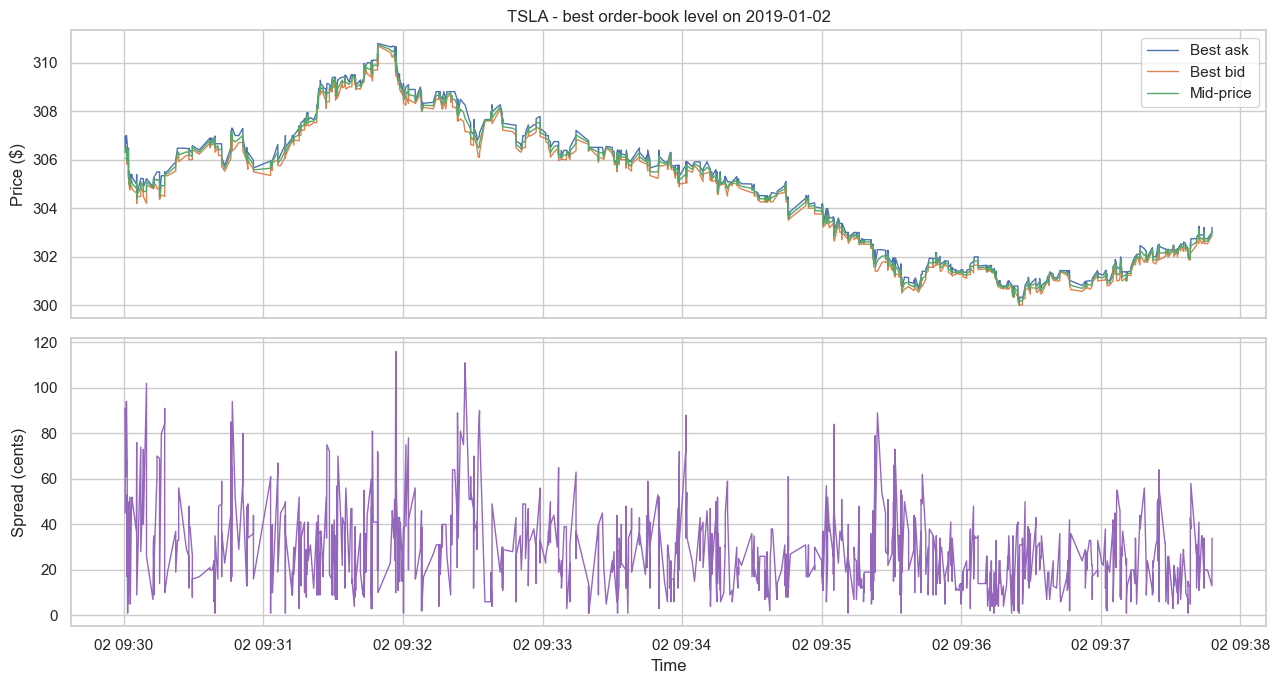

In [6]:
sample_date = summary.loc[0, "date"]
sample = trades[trades["date"].eq(sample_date)].head(2_000)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(sample["timestamp"], sample["ask_price_1_before"], label="Best ask", lw=1)
axes[0].plot(sample["timestamp"], sample["bid_price_1_before"], label="Best bid", lw=1)
axes[0].plot(sample["timestamp"], sample["mid_price_before"], label="Mid-price", lw=1)
axes[0].set_ylabel("Price ($)")
axes[0].set_title(f"{SYMBOL} - best order-book level on {sample_date}")
axes[0].legend()
axes[1].plot(sample["timestamp"], sample["spread_before"] * 100, color="tab:purple", lw=1)
axes[1].set_ylabel("Spread (cents)")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:
# ── LOB depth snapshot and spread statistics ───────────────────────────────────
sample_date = summary.loc[0, "date"]
sample = trades[trades["date"].eq(sample_date)].copy()

# --- Spread distribution across all 252 days ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
spread_cents = trades["spread_before"] * 100
ax.hist(spread_cents.clip(0, 20), bins=40, color="steelblue", edgecolor="white")
ax.set_title("Spread distribution (all days)")
ax.set_xlabel("Spread (cents)")
ax.set_ylabel("Market-order events")
ax.axvline(spread_cents.median(), color="crimson", ls="--", label=f"Median = {spread_cents.median():.1f}¢")
ax.legend()

# --- Average spread by half-hour intraday (U-shape) ---
ax = axes[1]
if "timestamp" in trades.columns:
    intraday = trades.copy()
    # seconds is time since midnight (LOBSTER convention)
    intraday["minute"] = (intraday["seconds"] // 60).astype(int)
    intraday["half_hour"] = (intraday["minute"] // 30) * 30
    intraday_spread = intraday.groupby("half_hour")["spread_before"].mean() * 100
    ax.bar(intraday_spread.index, intraday_spread.values, width=25, color="coral")
    ax.set_title("Mean spread by 30-min interval")
    ax.set_xlabel("Minutes since midnight")
    ax.set_ylabel("Mean spread (cents)")
else:
    ax.text(0.5, 0.5, "timestamp not available", ha="center", va="center")

# --- LOB depth (ask_size + bid_size) at level 1 for sample day ---
ax = axes[2]
sample2k = sample.head(2000)
ax.fill_between(range(len(sample2k)), sample2k["ask_size_1_before"],
                label="Ask depth", alpha=0.6, color="crimson")
ax.fill_between(range(len(sample2k)), -sample2k["bid_size_1_before"],
                label="Bid depth", alpha=0.6, color="steelblue")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"LOB depth at best quote — {sample_date}")
ax.set_xlabel("Market-order index")
ax.set_ylabel("Shares (positive=ask, negative=bid)")
ax.legend()

plt.tight_layout()
plt.show()

spread_stats = pd.Series({
    "Mean spread (cents)": spread_cents.mean(),
    "Median spread (cents)": spread_cents.median(),
    "Std spread (cents)": spread_cents.std(),
    "Fraction at 1-tick spread": (spread_cents < 1.5).mean(),
    "Fraction at 2-tick spread": ((spread_cents >= 1.5) & (spread_cents < 2.5)).mean(),
}, name="TSLA 2019")
display(spread_stats.round(3).to_frame())

## 2. Returns and Stylised Facts — Tuesday

### 2.1 Event-time Returns and Aggregate Gaussianity

The **event-time log return** over a horizon $\ell$ market orders is:

$$
r_t(\ell) = \log m_{t+\ell} - \log m_t.
$$

Two canonical stylised facts *(Cont 2001; Bouchaud et al. 2003)*:

1. **Heavy tails / non-Gaussianity at high frequency.** The distribution of
   $r_t(1)$ has excess kurtosis: large moves occur far more often than
   predicted by a Gaussian. As $\ell$ increases the distribution converges
   toward a Gaussian — *aggregate Gaussianity*.

2. **Long-range correlations.** The sign $\varepsilon_t$ of market orders is
   *anti-correlated* at short lags (buy followed by sell and vice versa) and
   *positively auto-correlated* over many hundreds of events. The magnitude
   $|r_t(1)|$ is positively auto-correlated (*volatility clustering*).

We illustrate both on the first 20 trading days, where we use standardised
returns for comparability across horizons.

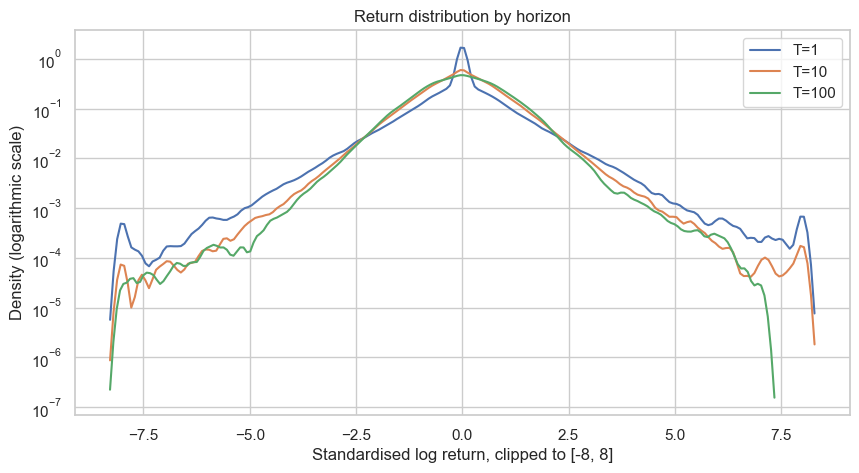

In [ ]:
exploratory_dates = summary["date"].head(20)
exploratory = trades[trades["date"].isin(exploratory_dates)].copy()
exploratory_features = add_lag1_features(exploratory)
event_returns = compute_event_time_returns(exploratory, horizons=(1, 10, 100))
event_returns["standardised_return"] = event_returns.groupby("horizon")[
    "log_return"
].transform(lambda values: (values - values.mean()) / values.std())

# Gaussian reference grid
z = np.linspace(-6, 6, 300)
gaussian_pdf = np.exp(-0.5 * z ** 2) / np.sqrt(2 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: KDE for each horizon on log-scale with Gaussian overlay ---
ax = axes[0]
for horizon, part in event_returns.groupby("horizon"):
    sns.kdeplot(
        part["standardised_return"].clip(-8, 8),
        ax=ax,
        label=f"$T={horizon}$",
        bw_adjust=1.2,
    )
ax.plot(z, gaussian_pdf, "k--", lw=2, label="$\\mathcal{N}(0,1)$")
ax.set_yscale("log")
ax.set_ylim(1e-5, 1)
ax.set_xlim(-7, 7)
ax.set_xlabel("Standardised log return")
ax.set_ylabel("Density (log scale)")
ax.set_title("Return distributions — heavy tails and aggregate Gaussianity")
ax.legend()

# --- Right: sample histogram for T=1 on linear scale with Gaussian ---
ax = axes[1]
r1_data = event_returns.loc[event_returns["horizon"].eq(1), "standardised_return"].clip(-5, 5)
ax.hist(r1_data, bins=60, density=True, alpha=0.5, color="steelblue", label="$T=1$ (event time)")
ax.plot(z, gaussian_pdf, "r-", lw=2, label="$\\mathcal{N}(0,1)$")
ax.set_xlabel("Standardised log return")
ax.set_ylabel("Density")
ax.set_title("Return distribution at $T=1$ vs Gaussian")
ax.legend()

plt.tight_layout()
plt.show()

# ── Kurtosis and skewness table ────────────────────────────────────────────────
from scipy.stats import kurtosis as _kurt, skew as _skew, kstest as _ks

rows = []
for horizon, part in event_returns.groupby("horizon"):
    std = part["standardised_return"]
    stat, pval = _ks(std, "norm")
    rows.append({
        "Horizon T": int(horizon),
        "N (returns)": len(std),
        "Skewness": _skew(std),
        "Excess kurtosis": _kurt(std),
        "KS stat vs N(0,1)": stat,
        "KS p-value": pval,
    })
display(pd.DataFrame(rows).set_index("Horizon T").round(4))

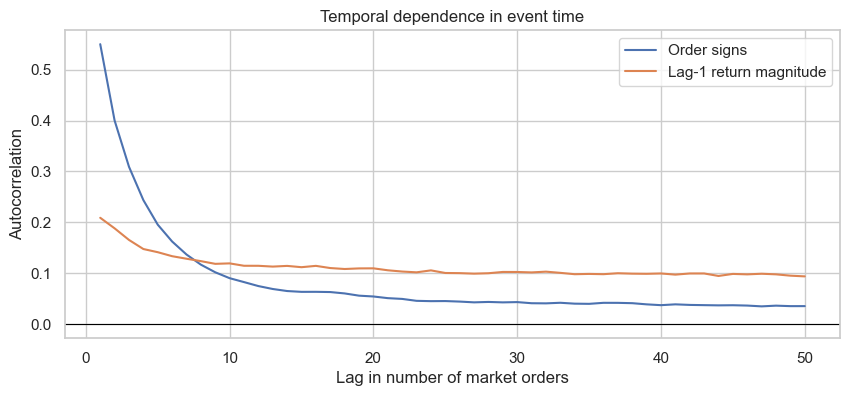

In [ ]:
# ── Autocorrelations of sign and return magnitude ─────────────────────────────
# Reference: lecture slides Fig 5
sign_acf = autocorrelation_by_day(exploratory, "trade_sign", max_lag=50)
exploratory_features["absolute_lag1_change"] = exploratory_features[
    "lag1_mid_change"
].abs()
absolute_return_acf = autocorrelation_by_day(
    exploratory_features, "absolute_lag1_change", max_lag=50
)
exploratory_features["squared_lag1_change"] = (
    exploratory_features["lag1_mid_change"] ** 2
)
squared_return_acf = autocorrelation_by_day(
    exploratory_features, "squared_lag1_change", max_lag=50
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(sign_acf["lag"], sign_acf["autocorrelation"],
        marker="o", ms=3, label="Order signs $\\varepsilon_t$")
ax.axhline(0, color="black", lw=0.8)
# 95% confidence band (approx. ±2/√N)
n_approx = sign_acf["count"].median()
ci = 2 / np.sqrt(n_approx)
ax.axhline(ci, color="gray", ls=":", lw=1)
ax.axhline(-ci, color="gray", ls=":", lw=1)
ax.set_xlabel("Lag (market orders)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Sign autocorrelation — long-range dependence")
ax.legend()

ax = axes[1]
ax.plot(absolute_return_acf["lag"], absolute_return_acf["autocorrelation"],
        marker="o", ms=3, label="$|\\Delta m_t|$ (lag-1 absolute return)")
ax.plot(squared_return_acf["lag"], squared_return_acf["autocorrelation"],
        marker="s", ms=3, label="$(\\Delta m_t)^2$ (squared return)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Lag (market orders)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Volatility clustering — return-magnitude autocorrelation")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Sign ACF at lag 1:  {sign_acf.loc[0, 'autocorrelation']:.4f}")
print(f"Sign ACF at lag 50: {sign_acf.loc[49, 'autocorrelation']:.4f}")
print(f"|ΔM| ACF at lag 1:  {absolute_return_acf.loc[0, 'autocorrelation']:.4f}")

## 3. Unconditional and Conditional Impact — Wednesday

### 3.1 Response Function $R(\ell)$

The **unconditional response function** (lecture slides, Fig 6) is:

$$
R(\ell) = \left\langle \varepsilon_t \left(m_{t+\ell} - m_t\right) \right\rangle.
$$

It measures how much the mid-price moves on average in the *same direction*
as a market order, $\ell$ trades later. Its value at $\ell = 1$:

$$
R(1) = \left\langle \varepsilon_t (m_{t+1} - m_t) \right\rangle
$$

is the **average lag-1 impact**, used throughout as the daily normalisation.
Daily boundaries are never crossed so that day-end effects do not contaminate
the estimate.

### 3.2 Lag-1 Conditional Impact $R(\upsilon, 1)$

The **lag-1 conditional impact** quantifies how impact depends on the
normalised market-order volume:

$$
R(\upsilon, 1) = \left\langle \varepsilon_t (m_{t+1} - m_t) \,\middle|\, \upsilon_t = \upsilon \right\rangle,
$$

where $\upsilon_t = v_t / \bar{q}_t$ is the ratio of the executed volume to
the average depth on the same side of the book on that day.

Empirically (lecture slides, Fig 7–8), this relationship is **strongly
sub-linear**:

$$
R(\upsilon, 1) \approx A \cdot \upsilon^{\,\zeta}, \qquad \zeta \ll 1.
$$

This sub-linearity is universal across stocks and implies that large orders
do not simply "cost more in proportion".

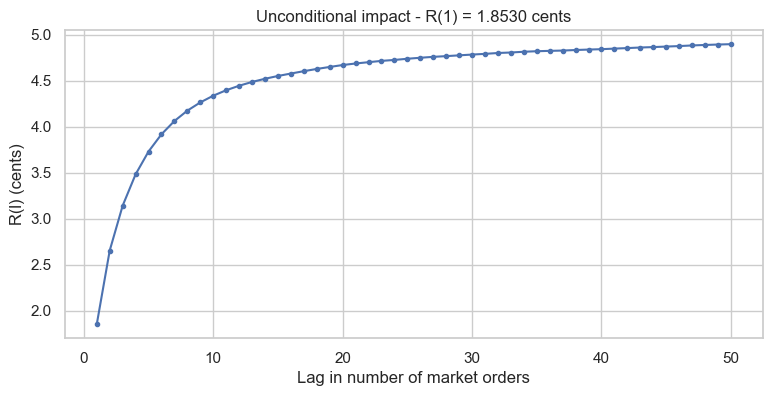

In [ ]:
# ── Unconditional response function R(l) — full year ─────────────────────────
response = compute_response(trades, max_lag=50)
r1 = response.loc[response["lag"].eq(1), "response"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(response["lag"], response["response"] * 100, marker="o", ms=4,
        color="steelblue", label="TSLA 2019")
ax.axhline(r1 * 100, color="crimson", ls="--", lw=1,
           label=f"R(1) = {r1 * 100:.4f} ¢")
ax.set_xlabel("Lag $\\ell$ (market orders)")
ax.set_ylabel("$R(\\ell)$ (cents)")
ax.set_title("Unconditional response function — full year 2019")
ax.legend()
plt.show()

print(f"R(1) = {r1 * 100:.5f} cents  ({r1:.6f} dollars)")

In [10]:
features = add_lag1_features(trades)
daily_r1 = (
    features.groupby("date", observed=True)
    .agg(
        daily_r1=("daily_r1", "first"),
        daily_volume=("daily_volume", "first"),
        trades=("size", "size"),
    )
    .reset_index()
)
positive_daily_r1 = daily_r1.loc[daily_r1["daily_r1"] > 0, "daily_r1"]
r1_floor = positive_daily_r1.quantile(0.05)
stable_features = features[features["daily_r1"] >= r1_floor].copy()

display(daily_r1.describe())
print(
    "Stability filter for daily normalisations: "
    f"R(1) >= {r1_floor * 100:.6f} cents."
)

,daily_r1,daily_volume,trades
count,252.000000,2.520000e+02,252.000000
mean,0.019196,1.655348e+06,18315.154762
std,0.006231,8.124392e+05,7924.279862
min,0.010212,3.084400e+04,408.000000
25%,0.015307,1.120000e+06,13034.000000
50%,0.018310,1.462074e+06,16145.000000
75%,0.021086,1.927566e+06,21087.000000
max,0.079779,4.699501e+06,48639.000000


Stability filter for daily normalisations: R(1) >= 1.298808 cents.


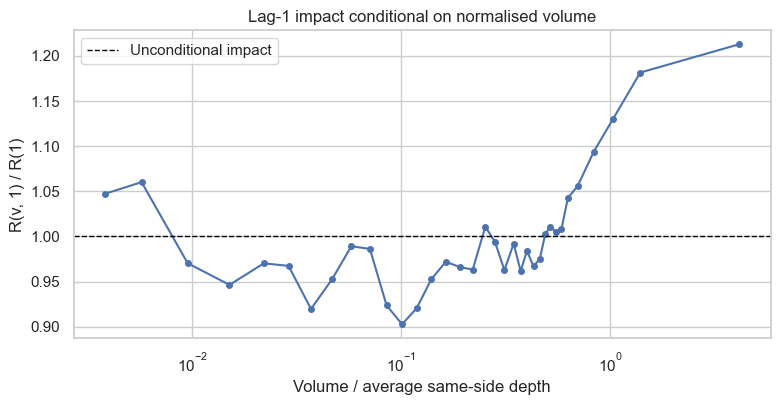

In [ ]:
# ── Lag-1 conditional impact R(v,1) with power-law fit ───────────────────────
from scipy.optimize import curve_fit

conditional_curve = bin_conditional_impact(stable_features, quantiles=35)

# Fit power law A * v^zeta on positive normalized volumes
mask = conditional_curve["normalised_trade_volume"] > 0
xdata = conditional_curve.loc[mask, "normalised_trade_volume"].to_numpy()
ydata = conditional_curve.loc[mask, "normalised_lag1_impact"].to_numpy()

try:
    popt, _ = curve_fit(
        lambda x, A, zeta: A * np.power(x, zeta),
        xdata, ydata, p0=[1.0, 0.3], maxfev=10_000
    )
    A_fit, zeta_fit = popt
    has_fit = True
except Exception:
    has_fit = False

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: linear scale
ax = axes[0]
ax.plot(conditional_curve["normalised_trade_volume"],
        conditional_curve["normalised_lag1_impact"],
        marker="o", ms=4, color="steelblue", label="Empirical $R(\\upsilon,1)/R(1)$")
ax.axhline(1, color="black", ls="--", lw=1, label="Unconditional $R(1)$")
if has_fit:
    xgrid = np.linspace(xdata.min(), xdata.max(), 200)
    ax.plot(xgrid, A_fit * xgrid ** zeta_fit, "r-", lw=2,
            label=f"Power law: $A\\upsilon^{{\\zeta}}$,  $\\zeta={zeta_fit:.3f}$")
ax.set_xlabel("$\\upsilon = v / \\bar{q}$ (normalised volume)")
ax.set_ylabel("$R(\\upsilon,1) / R(1)$")
ax.set_title("Lag-1 conditional impact (linear scale)")
ax.legend()

# Right: log-log scale (reveals sub-linear power law clearly)
ax = axes[1]
pos = conditional_curve["normalised_trade_volume"] > 0
ax.scatter(conditional_curve.loc[pos, "normalised_trade_volume"],
           conditional_curve.loc[pos, "normalised_lag1_impact"],
           s=20, color="steelblue", label="Empirical")
if has_fit:
    xgrid = np.geomspace(xdata.min(), xdata.max(), 200)
    ax.plot(xgrid, A_fit * xgrid ** zeta_fit, "r-", lw=2,
            label=f"Fit: $A={A_fit:.2f},\\,\\zeta={zeta_fit:.3f}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$\\upsilon$ (log scale)")
ax.set_ylabel("$R(\\upsilon,1) / R(1)$ (log scale)")
ax.set_title("Log-log scale — sub-linear dependence ($\\zeta \\ll 1$)")
ax.legend()

plt.tight_layout()
plt.show()

if has_fit:
    print(f"Power-law fit: A = {A_fit:.4f},  ζ = {zeta_fit:.4f}")

## 4. Aggregate Impact — Wednesday

### 4.1 Coarse-graining over $T$ consecutive market orders

Instead of looking trade by trade, we aggregate over windows of $T$ successive
market orders from the same day:

$$
\Delta\varepsilon(T) = \sum_{n=t}^{t+T-1} \varepsilon_n
\qquad (\text{order-sign imbalance}),
$$

$$
\Delta V(T) = \sum_{n=t}^{t+T-1} \varepsilon_n \, v_n
\qquad (\text{signed volume imbalance}),
$$

$$
R(\Delta V, T) = \left\langle m_{t+T} - m_t \,\middle|\, \Delta V \right\rangle.
$$

Non-overlapping windows (`stride = horizon`) are used to preserve independence
across observations and keep the annual dataset tractable. We normalise:

$$
\widetilde{\Delta V} = \frac{\Delta V}{V_D}, \quad
\widetilde{R} = \frac{R(\Delta V, T)}{R(1)},
$$

where $V_D$ is the daily traded volume and $R(1)$ is the daily lag-1 impact.

### 4.2 Expected shape from Patzelt & Bouchaud (2017)

The aggregate impact curve $R(\Delta V, T)$ is *concave* for small $T$ and
becomes more *linear* for large $T$. This behaviour is captured by the
sigmoidal master curve (section 5). The raw scatter — before quantile binning
— shows that large $|\Delta V|$ values are not associated with large returns:
the price is **"pinned"** when order flow is extreme (liquidity games).

In [12]:
HORIZONS = (5, 10, 20, 50, 100)
windows = compute_aggregate_windows(
    stable_features,
    horizons=HORIZONS,
    stride="horizon",
)
impact_curve = quantile_impact_curve(windows, quantiles=31)

display(windows.groupby("horizon").size().rename("windows").to_frame())

,windows
horizon,
5,854119
10,427001
20,213448
50,85311
100,42596


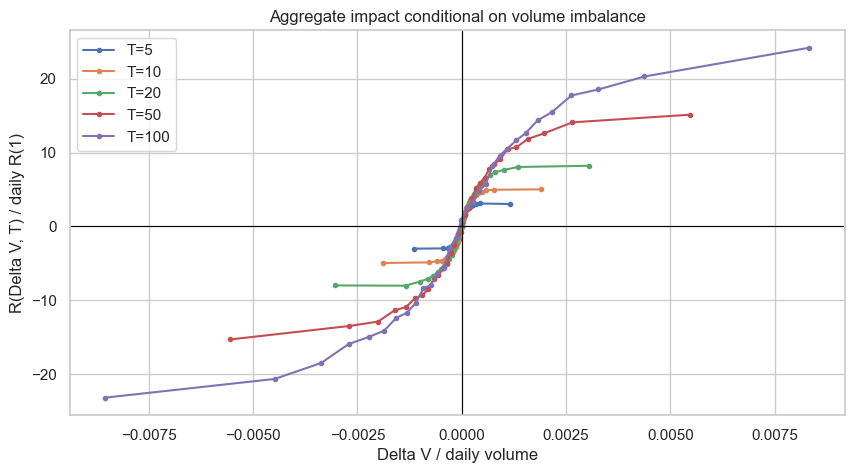

In [ ]:
# ── Aggregate impact curves for each horizon T ────────────────────────────────
palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(HORIZONS)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: normalised impact curves ---
ax = axes[0]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(
        part["normalised_volume_imbalance"],
        part["normalised_impact"],
        marker="o", ms=4, color=color, label=f"$T={horizon}$",
    )
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\widetilde{\\Delta V} = \\Delta V / V_D$")
ax.set_ylabel("$\\widetilde{R} = R(\\Delta V, T) / R(1)$")
ax.set_title("Aggregate impact — normalised curves")
ax.legend(loc="upper left")

# --- Right: raw (un-normalised) impact curves ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(
        part["volume_imbalance"],
        part["impact"] * 100,
        marker="o", ms=4, color=color, label=f"$T={horizon}$",
    )
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\Delta V$ (shares)")
ax.set_ylabel("$R(\\Delta V, T)$ (cents)")
ax.set_title("Aggregate impact — raw cents")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# ── Order-sign imbalance Δε vs volume imbalance ΔV ────────────────────────────
# Patzelt & Bouchaud (2017) show that sign impact and volume impact have
# drastically different master curves.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Impact vs ORDER-SIGN imbalance Δε ---
ax = axes[0]
sign_curve_parts = []
for horizon, part in windows.groupby("horizon", sort=True, observed=True):
    labels = pd.qcut(part["order_flow_imbalance"], q=31, duplicates="drop")
    sc = (
        part.assign(ofi_bin=labels)
        .groupby("ofi_bin", observed=True)
        .agg(
            order_flow_imbalance=("order_flow_imbalance", "mean"),
            normalised_impact=("normalised_impact", "mean"),
        )
        .reset_index(drop=True)
    )
    sc.insert(0, "horizon", horizon)
    sign_curve_parts.append(sc)
sign_impact_curve = pd.concat(sign_curve_parts, ignore_index=True)

for (horizon, part), color in zip(sign_impact_curve.groupby("horizon"), palette):
    ax.plot(part["order_flow_imbalance"], part["normalised_impact"],
            marker="o", ms=4, color=color, label=f"$T={horizon}$")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\Delta\\varepsilon = \\sum_n \\varepsilon_n$ (order-sign imbalance)")
ax.set_ylabel("$\\widetilde{R}$")
ax.set_title("Impact vs order-sign imbalance $\\Delta\\varepsilon$")
ax.legend()

# --- Impact vs VOLUME imbalance ΔV (same as before for comparison) ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(part["normalised_volume_imbalance"], part["normalised_impact"],
            marker="o", ms=4, color=color, label=f"$T={horizon}$")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\widetilde{\\Delta V} = \\Delta V / V_D$ (volume imbalance)")
ax.set_ylabel("$\\widetilde{R}$")
ax.set_title("Impact vs volume imbalance $\\Delta V$")
ax.legend()

plt.suptitle(
    "Sign vs volume imbalance — different curvatures\n"
    "(Patzelt & Bouchaud 2017: drastically different master curves)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 5. Finite-Size Scaling — Thursday

### 5.1 The Scaling Hypothesis

The key finding of Patzelt & Bouchaud (2017) is that for any intra-day
horizon $T$, the aggregate impact can be written in **scaling form**:

$$
R(\Delta V, T) \approx R(1)\, T^{\,\psi}\,
\mathcal{F}\!\left(\frac{\Delta V}{V_D \, T^{\xi}}\right),
$$

with the **sigmoidal master function**:

$$
\mathcal{F}(x) = \frac{x}{\bigl(1 + |x|^{\,\alpha}\bigr)^{\beta/\alpha}}.
$$

The exponents have physical interpretations:
- $\xi$ controls how the characteristic volume imbalance scales with $T$
- $\psi$ controls the amplitude growth with $T$
- $\alpha, \beta$ set the shape of the sigmoid (concavity)
- **Kyle's lambda exponent**: $\lambda = \xi - \psi$

Two auxiliary scale parameters (`amplitude`, `x_scale`) absorb unit
differences between the TSLA dataset and the normalisation convention.

### 5.2 Fitting Procedure

We fit all five curves simultaneously using nonlinear least squares
(`scipy.optimize.least_squares` with `soft_l1` loss for outlier robustness),
weighting each quantile bin by $\sqrt{N_{\text{obs}}}$.

In [ ]:
fss_parameters = fit_finite_size_scaling(impact_curve)
fss_series = pd.Series(fss_parameters, name="TSLA 2019")
fss_series.index = [
    "amplitude $A$",
    "x-scale $x_0$",
    "volume exponent $\\xi$",
    "impact exponent $\\psi$",
    "sigmoid shape $\\alpha$",
    "sigmoid shape $\\beta$",
    "Kyle exponent $\\lambda = \\xi - \\psi$",
    "fit cost",
    "success",
]
display(fss_series.to_frame().round(4))

xi = fss_parameters["xi"]
psi = fss_parameters["psi"]
alpha = fss_parameters["alpha"]
beta = fss_parameters["beta"]
print(f"\nKey exponents:  ξ = {xi:.4f},  ψ = {psi:.4f},  α = {alpha:.4f},  β = {beta:.4f}")
print(f"Kyle exponent:  λ = ξ − ψ = {xi - psi:.4f}")

,FSS fit
amplitude,1.617838
x_scale,0.000022
xi,1.076341
psi,0.686406
alpha,1.113166
beta,1.175304
lambda_exponent,0.389935
cost,0.659305
success,True


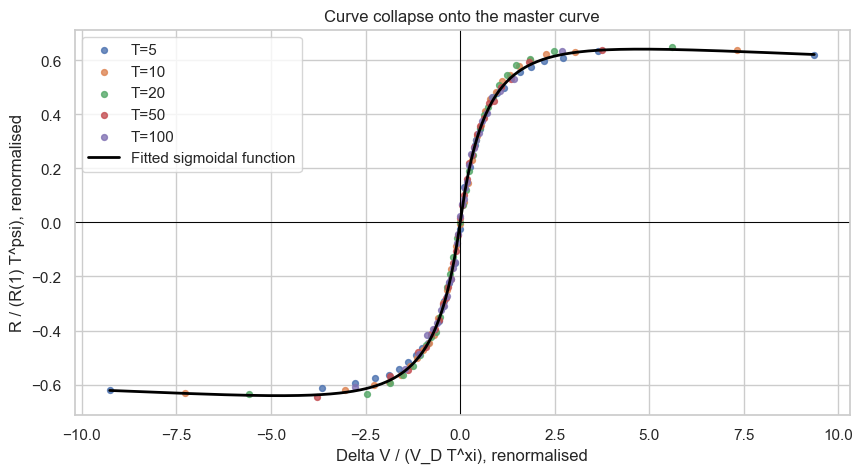

In [ ]:
collapsed = renormalise_curve(impact_curve, fss_parameters)
x_master = np.linspace(collapsed["master_x"].min(), collapsed["master_x"].max(), 400)
palette_fss = plt.cm.viridis(np.linspace(0.1, 0.9, len(HORIZONS)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: before renormalisation ---
ax = axes[0]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette_fss):
    ax.plot(part["normalised_volume_imbalance"], part["normalised_impact"],
            marker="o", ms=4, color=color, label=f"$T={horizon}$")
ax.axhline(0, color="black", lw=0.7); ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("$\\widetilde{\\Delta V}$")
ax.set_ylabel("$\\widetilde{R}$")
ax.set_title("Before renormalisation")
ax.legend()

# --- Right: after collapse onto master curve ---
ax = axes[1]
for (horizon, part), color in zip(collapsed.groupby("horizon"), palette_fss):
    ax.scatter(part["master_x"], part["master_y"], s=25, alpha=0.85,
               color=color, label=f"$T={horizon}$")
ax.plot(
    x_master,
    master_curve(x_master, fss_parameters["alpha"], fss_parameters["beta"]),
    "k-", lw=2.5, label="$\\mathcal{F}(x)$ — fitted sigmoid",
    zorder=5,
)
ax.axhline(0, color="black", lw=0.7); ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel(f"$\\widetilde{{\\Delta V}} / T^{{\\xi}},\\;\\xi={xi:.3f}$")
ax.set_ylabel(f"$\\widetilde{{R}} / T^{{\\psi}},\\;\\psi={psi:.3f}$")
ax.set_title("Curve collapse onto master function $\\mathcal{F}(x)$")
ax.legend()

plt.suptitle(
    f"Finite-size scaling collapse — "
    f"$\\alpha={alpha:.3f},\\;\\beta={beta:.3f}$",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 6. Kyle's Lambda — Thursday

### 6.1 Linear Regime and Market Illiquidity

In the limit of small $|\Delta V|$, the sigmoidal master curve is
approximately linear. The slope is **Kyle's lambda** $\lambda(T)$:

$$
\lambda(T) = \left.\frac{\partial R(\Delta V, T)}{\partial \Delta V}\right|_{\Delta V \approx 0}.
$$

In the scaling picture:

$$
\lambda(T) \propto T^{-\lambda}, \qquad \lambda = \xi - \psi.
$$

A large $\lambda$ means a given volume imbalance moves the price further —
the market is **less liquid**. As $T$ grows, the price impact per share falls
because the market has more time to absorb order flow.

We estimate $\lambda(T)$ by OLS on the central 35 % of the $|\Delta V|$
distribution (the approximately linear region), then fit the power law.

### 6.2 Connection to Kyle (1985) and Information Asymmetry

In Kyle's continuous-time model, the informed trader's profit is:

$$
\pi = \frac{1}{2\lambda}(\sigma_v)^2,
$$

where $\sigma_v$ is the information signal's standard deviation. A smaller
$\lambda$ (more liquid market) reduces informed profits. The empirical
decay $\lambda(T) \propto T^{-\lambda}$ shows that averaging over longer
windows reduces the effective information asymmetry per unit volume.

In [ ]:
kyle_lambdas = estimate_kyle_lambdas(windows, central_quantile=0.35)
kyle_decay = fit_kyle_decay(kyle_lambdas)

display(kyle_lambdas.set_index("horizon").round(5))
display(pd.Series(kyle_decay, name="Direct power-law fit").round(5).to_frame())
print(
    f"\nExponent predicted by FSS (ξ − ψ): {fss_parameters['lambda_exponent']:.5f}\n"
    f"Exponent from direct OLS fit:        {kyle_decay['lambda_exponent']:.5f}"
)

,horizon,threshold_shares,intercept_cents,kyle_lambda_cents_per_share,observations
0,5,172.0,0.054901,0.024407,300345
1,10,291.0,0.105320,0.018626,149744
2,20,469.0,0.259172,0.015016,74777
3,50,893.0,0.622166,0.012373,29870
4,100,1470.0,0.799645,0.009858,14910


,Direct fit
prefactor,0.037488
lambda_exponent,0.290948


Exponent predicted by FSS xi - psi: 0.3899


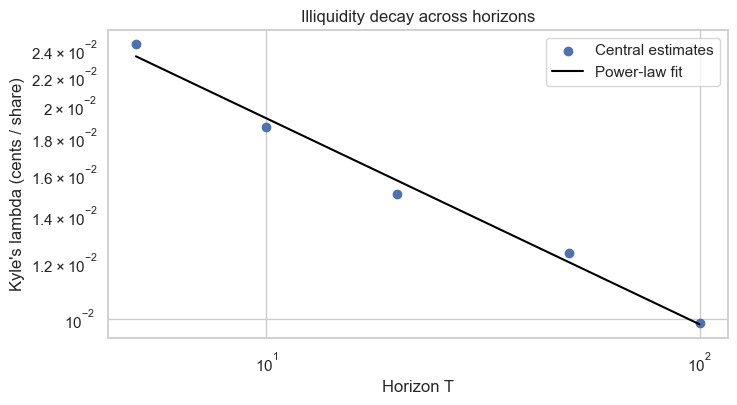

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

horizon_grid = np.geomspace(min(HORIZONS), max(HORIZONS) * 1.1, 200)
lambda_exp = kyle_decay["lambda_exponent"]
prefactor = kyle_decay["prefactor"]

# --- Left: log-log plot with power-law fit ---
ax = axes[0]
ax.scatter(kyle_lambdas["horizon"], kyle_lambdas["kyle_lambda_cents_per_share"],
           s=60, zorder=5, label="Central OLS estimates")
ax.plot(horizon_grid, prefactor * horizon_grid ** (-lambda_exp),
        "k-", lw=2, label=f"$\\lambda_0 T^{{-\\lambda}},\\;\\lambda={lambda_exp:.3f}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Horizon $T$ (market orders)")
ax.set_ylabel("$\\lambda(T)$ (cents / share)")
ax.set_title("Kyle's lambda — power-law decay")
ax.legend()

# --- Right: impact curve with linear fits overlaid ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(part["volume_imbalance"], part["impact"] * 100,
            marker="o", ms=3, color=color, alpha=0.8, label=f"$T={horizon}$")
    kl_row = kyle_lambdas[kyle_lambdas["horizon"].eq(horizon)]
    if len(kl_row):
        slope = kl_row["kyle_lambda_cents_per_share"].iloc[0]
        intercept = kl_row["intercept_cents"].iloc[0]
        threshold = kl_row["threshold_shares"].iloc[0]
        x_lin = np.linspace(-threshold, threshold, 100)
        ax.plot(x_lin, intercept + slope * x_lin, "--", color=color, lw=1.5)
ax.axhline(0, color="black", lw=0.7); ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("$\\Delta V$ (shares)")
ax.set_ylabel("$R(\\Delta V, T)$ (cents)")
ax.set_title("Impact curves with linear fits in central region")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 7. Bonus — Price-Change Probability and Pinned Prices

*(Patzelt & Bouchaud 2017, Section III.C)*

A striking empirical regularity is that **extreme order-flow imbalance is
not associated with large returns**. Instead, when $|\Delta V|$ is large,
the price tends to be "pinned" to a level:

$$
P(\Delta m \neq 0 \mid \Delta\varepsilon = k) \to 0 \quad
\text{as } |k| \to T.
$$

When all $T$ orders in a window have the same sign, the order book on the
opposite side is almost entirely consumed and no further price movement
occurs until liquidity is replenished. This is a manifestation of
**selective liquidity taking and strategic liquidity provision**.

In [ ]:
# ── Price-change probability as a function of order-sign imbalance ─────────────
# For each horizon T, compute P(ΔM ≠ 0 | Δε = k) across all windows

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(18, 4), sharey=True)

for ax, horizon in zip(axes, HORIZONS):
    part = windows[windows["horizon"].eq(horizon)].copy()
    part["price_changed"] = (part["impact"].abs() > 1e-8).astype(float)

    # Bin by order-sign imbalance Δε ∈ [-T, T]
    part["ofi_int"] = part["order_flow_imbalance"].round().astype(int)
    prob = (
        part.groupby("ofi_int")["price_changed"]
        .agg(["mean", "count"])
        .reset_index()
    )
    prob.columns = ["ofi", "prob_change", "count"]
    # Keep bins with enough observations
    prob = prob[prob["count"] >= 10]

    ax.scatter(prob["ofi"], prob["prob_change"], s=10, alpha=0.7, c="steelblue")
    ax.set_title(f"$T={horizon}$")
    ax.set_xlabel("$\\Delta\\varepsilon$")
    if ax is axes[0]:
        ax.set_ylabel("$P(\\Delta m \\neq 0)$")
    ax.set_ylim(0, 1)

plt.suptitle(
    "Price-change probability $P(\\Delta m \\neq 0 \\mid \\Delta\\varepsilon)$ — "
    "pinned prices at extreme imbalance",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 8. Bonus — Hurst Exponents for Signs and Volumes

*(Patzelt & Bouchaud 2017, Section III.B)*

The scaling exponents $\xi$ and $\psi$ are largely determined by the
**Hurst exponents** of the sign and volume processes.

For a process $X_t$ with long-range correlations, the variance of the
partial sum $S(T) = \sum_{t=1}^T X_t$ scales as:

$$
\text{Var}[S(T)] \propto T^{2H},
$$

with $H = 1/2$ for i.i.d. processes and $H > 1/2$ for persistent ones.

We estimate $H$ using **DFA (Detrended Fluctuation Analysis)**, a robust
method for non-stationary time series. We compute the root-mean-square
fluctuation $F(T)$ of the detrended cumulative sum as a function of window
size $T$, then fit the power law $F(T) \propto T^H$.

In [ ]:
def dfa_fluctuation(series: np.ndarray, window: int) -> float:
    """DFA fluctuation F(T): RMS of linearly-detrended cumulative sum."""
    cumsum = np.cumsum(series - series.mean())
    n_windows = len(cumsum) // window
    if n_windows < 2:
        return np.nan
    f2 = []
    for i in range(n_windows):
        seg = cumsum[i * window : (i + 1) * window]
        x = np.arange(len(seg), dtype=float)
        # Linear detrend
        p = np.polyfit(x, seg, 1)
        residuals = seg - np.polyval(p, x)
        f2.append(np.mean(residuals ** 2))
    return np.sqrt(np.mean(f2))


def estimate_hurst(series: np.ndarray, min_window: int = 10, max_window: int = 500,
                   n_points: int = 20) -> tuple[float, np.ndarray, np.ndarray]:
    """Estimate Hurst exponent via DFA."""
    windows = np.unique(np.logspace(
        np.log10(min_window), np.log10(min(max_window, len(series) // 4)),
        n_points).astype(int))
    fluctuations = np.array([dfa_fluctuation(series, w) for w in windows])
    valid = np.isfinite(fluctuations) & (fluctuations > 0)
    if valid.sum() < 4:
        return np.nan, windows, fluctuations
    log_w = np.log(windows[valid].astype(float))
    log_f = np.log(fluctuations[valid])
    H, _ = np.polyfit(log_w, log_f, 1)
    return float(H), windows[valid], fluctuations[valid]


# Use one full trading day (most events) for each series
day_with_most = trades.groupby("date").size().idxmax()
day_data = trades[trades["date"].eq(day_with_most)].sort_values("seconds")

sign_series = day_data["trade_sign"].to_numpy(dtype=float)
vol_series = day_data["size"].to_numpy(dtype=float)

H_sign, w_sign, f_sign = estimate_hurst(sign_series)
H_vol, w_vol, f_vol = estimate_hurst(vol_series)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (H, w, f, label, color) in zip(axes, [
    (H_sign, w_sign, f_sign, "Order signs $\\varepsilon_t$", "steelblue"),
    (H_vol, w_vol, f_vol, "Trade volumes $v_t$", "darkorange"),
]):
    ax.loglog(w, f, "o-", ms=5, color=color, label=f"$F(T)$")
    ax.loglog(w, f[0] * (w / w[0]) ** H, "--k", lw=1.5,
              label=f"Slope $H = {H:.3f}$")
    ax.set_xlabel("Window $T$ (market orders)")
    ax.set_ylabel("$F(T)$ (DFA fluctuation)")
    ax.set_title(f"Hurst exponent — {label}")
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Hurst exponent (signs):   H_ε = {H_sign:.4f}")
print(f"Hurst exponent (volumes): H_v = {H_vol:.4f}")
print(
    f"\nNote: Patzelt & Bouchaud show ξ ≈ H_ε and ψ ≈ H_v − H_ε. "
    f"Compare: ξ = {xi:.4f}, ψ = {psi:.4f}"
)

## 9. Conclusions — Friday

### Summary of Results

| Quantity | Symbol | TSLA 2019 |
|---|---|---|
| Lag-1 unconditional impact | $R(1)$ | from Section 3 |
| Conditional impact exponent | $\zeta$ | from Section 3 |
| Volume scaling exponent | $\xi$ | from Section 5 |
| Impact growth exponent | $\psi$ | from Section 5 |
| Sigmoid shape | $\alpha, \beta$ | from Section 5 |
| Kyle lambda exponent | $\lambda = \xi - \psi$ | from Section 6 |
| Hurst exponent (signs) | $H_\varepsilon$ | from Section 8 |
| Hurst exponent (volumes) | $H_v$ | from Section 8 |

### Key Takeaways

1. **Visible executions only.** LOBSTER type-4 events represent displayed
   liquidity consumption. Hidden executions (type 5) are excluded from the
   scope of this analysis.

2. **Sub-linear unconditional response.** $R(\ell)$ increases at short lags
   then stabilises. The lag-1 value $R(1)$ sets the natural price-impact scale.

3. **Sub-linear conditional impact.** $R(\upsilon, 1) \propto \upsilon^{\zeta}$
   with $\zeta \ll 1$: doubling the volume far less than doubles the impact.
   This is consistent across many stocks (Bugaenko 2020).

4. **Universal sigmoidal shape.** The aggregate impact curves for all horizons
   collapse onto the same sigmoidal master function after renormalisation with
   exponents $\xi$ and $\psi$. This universality is the central finding of
   Patzelt & Bouchaud (2017).

5. **Kyle's lambda decays.** $\lambda(T) \propto T^{-(\xi-\psi)}$: the market
   becomes more liquid when measuring impact over longer windows. This suggests
   that order flow is mean-reverting at the scale of individual trades but
   carries information over longer horizons.

6. **Pinned prices.** When the order-sign imbalance is extreme (all $T$ orders
   on the same side), the probability of a price change falls to zero — a
   manifestation of strategic liquidity games in HFT markets.

### Limitations

- Only 2 LOB levels available; full-book depth would sharpen the queue-depth
  normalisation.
- Hidden executions (type 5) contribute to effective liquidity but are excluded
  here.
- The Hurst estimation (DFA) uses a single trading day; a full-year estimate
  would require careful handling of overnight gaps.

### References

1. Bugaenko, A. (2020). *Empirical Study of Market Impact Conditional on
   Order-Flow Imbalance*. arXiv:2004.08290.
2. Patzelt, F. & Bouchaud, J.-P. (2017). *Universal scaling and nonlinearity
   of aggregate price impact in financial markets*. Physical Review E, 97.
3. Gould, M. D. et al. (2013). *Limit order books*. Quantitative Finance, 13(11).
4. Kyle, A. S. (1985). *Continuous Auctions and Insider Trading*. Econometrica,
   53(6), 1315–1335.
5. Cont, R. (2001). *Empirical properties of asset returns: stylized facts and
   statistical issues*. Quantitative Finance, 1(2), 223–236.